In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('Churn_Modelling.csv')

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
data.shape

(10000, 14)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
data_nettoyer = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [11]:
data_nettoyer.shape

(10000, 11)

In [12]:
data_nettoyer.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [13]:
total_clients = len(data_nettoyer)
print(total_clients)

10000


In [14]:
clients_partis = data['Exited'].sum()
taux_partis= data['Exited'].mean() * 100

In [15]:
print(clients_partis)
print(taux_partis,'%')

2037
20.369999999999997 %


In [16]:
age_moyen = data['Age'].mean()
print(age_moyen,'ans')

38.9218 ans


In [21]:
pertes_clients_par_pays = data_nettoyer.groupby('Geography')['Exited'].mean() * 100
print("Taux de clients partis par pays",pertes_clients_par_pays,'%')

Taux de clients partis par pays Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64 %


In [22]:
pertes_par_sexe = data_nettoyer.groupby('Gender')['Exited'].mean() * 100
print("Taux de des clients partis par sexe", pertes_par_sexe)

Taux de des clients partis par sexe Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64 %


In [23]:
pertes_par_produits = data_nettoyer.groupby('NumOfProducts')['Exited'].mean() * 100
print("Taux de clients partis selon le nombre de produits", pertes_par_produits)

Taux de clients partis selon le nombre de produits NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64 %


In [24]:

pertes_par_activite = data_nettoyer.groupby('IsActiveMember')['Exited'].mean() * 100
print("Taux de partis des clients selon le statut actif", pertes_par_activite,)

Taux de partis des clients selon le statut actif IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64 %


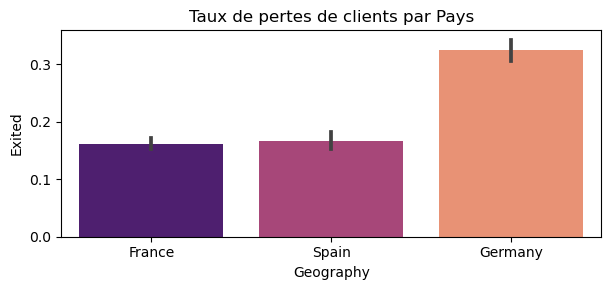

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (18, 3))
plt.subplot(1, 3, 2)
sns.barplot(x='Geography', y='Exited', data = data_nettoyer, palette = 'magma')
plt.title('Taux de pertes de clients par Pays')
plt.tight_layout()
plt.show()



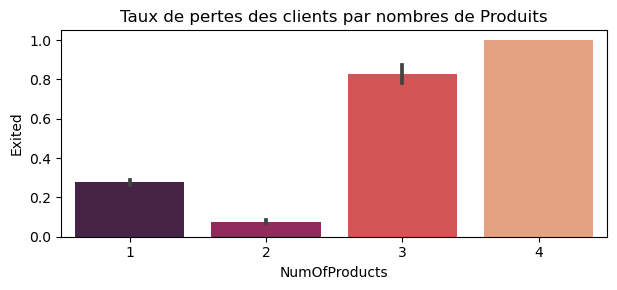

In [59]:
plt.figure(figsize = (18, 3))
plt.subplot(1, 3, 2)
sns.barplot(x='NumOfProducts', y='Exited', data = data_nettoyer, palette = 'rocket' )
plt.title('Taux de pertes des clients par nombres de Produits')
plt.tight_layout()
plt.show()

In [61]:
import os
os.getcwd()

'C:\\Users\\Admin'